In [1]:
from datetime import datetime
from tinkoff.invest import CandleInterval, Client
from tinkoff.invest.schemas import CandleSource
import pandas as pd
import numpy as np
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt
import statsmodels.api as sm

from dotenv import load_dotenv
import os

load_dotenv()

True

In [33]:
df = pd.read_csv("UcdpPrioConflict_v25_1.csv")
df_brent = pd.read_csv("DCOILBRENTEU.csv")
df.head()

,conflict_id,location,side_a,side_a_id,side_a_2nd,side_b,side_b_id,side_b_2nd,incompatibility,territory_name,...,ep_end,ep_end_date,ep_end_prec,gwno_a,gwno_a_2nd,gwno_b,gwno_b_2nd,gwno_loc,region,version
0,11342,India,Government of India,141,NaN,GNLA,1163,NaN,1,Garoland,...,1,2012-12-21,NaN,750,NaN,NaN,NaN,750,3,25.1
1,11342,India,Government of India,141,NaN,GNLA,1163,NaN,1,Garoland,...,1,2014-11-27,NaN,750,NaN,NaN,NaN,750,3,25.1
2,11343,"Egypt, Israel",Government of Egypt,117,NaN,Government of Israel,121,NaN,1,Suez/Sinai,...,1,1967-06-10,NaN,651,NaN,666,NaN,"651, 666",2,25.1
3,11343,"Egypt, Israel",Government of Egypt,117,NaN,Government of Israel,121,NaN,1,Suez/Sinai,...,0,NaN,NaN,651,NaN,666,NaN,"651, 666",2,25.1
4,11343,"Egypt, Israel",Government of Egypt,117,NaN,Government of Israel,121,NaN,1,Suez/Sinai,...,1,1970-08-07,NaN,651,NaN,666,NaN,"651, 666",2,25.1


In [41]:
# 2. Список ключевых нефтедобывающих локаций (согласно полю 'location')
# Мы включаем страны ОПЕК+ и регионы с важными проливами
oil_locations = [
    'Iraq', 'Iran', 'Kuwait', 'Saudi Arabia', 'Libya', 'United Arab Emirates',
    'Russia (Soviet Union)', 'Nigeria', 'Venezuela', 'Egypt', 'Syria', 'Azerbaijan'
]

# 3. Настройка фильтров
# type_of_conflict: 2 (interstate) и 4 (internationalized intrastate) — самые влиятельные
# intensity_level: 2 (War) — масштабные действия, вызывающие панику на бирже
# Также берем Minor (1), если это ключевой нефтедобытчик (напр. атаки в Саудовской Аравии)

mask = (
    # Фильтр по странам
    (df['location'].str.contains('|'.join(oil_locations), na=False)) &
    (
        # Либо это крупная война (любого типа в этих странах)
        (df['intensity_level'] == 2) |
        # Либо это межгосударственный конфликт (даже меньшей интенсивности)
        (df['type_of_conflict'] == 2) |
        # Либо это интернационализированный конфликт в ключевом регионе
        (df['type_of_conflict'] == 4)
    )
)

oil_conflicts = df[mask].copy()

# 4. Добавляем фильтр по годам великих шоков (опционально, для проверки)
# 1973 (Yom Kippur), 1979 (Iran Rev), 1980 (Iran-Iraq), 1990 (Gulf War), 2022 (Ukraine)
important_years = [1973, 1974, 1979, 1980, 1990, 1991, 2003, 2011, 2022, 2023, 2024]
oil_conflicts['is_major_shock_year'] = oil_conflicts['year'].isin(important_years)

# 5. Оставляем только нужные колонки для анализа
final_data = oil_conflicts[[
    'conflict_id', 'year', 'location', 'side_a', 'side_b',
    'type_of_conflict', 'intensity_level', 'is_major_shock_year', 'start_date2'
]]

# Сортируем по году для удобства
final_data = final_data.sort_values(by='year', ascending=False)

# Сохраняем результат
final_data.to_csv('oil_market_conflicts.csv', index=False)

print(f"Найдено конфликтов: {len(final_data)}")
# print(final_data.head(10))

final_data["location"].unique()

Найдено конфликтов: 151


/tmp/ipykernel_30903/228827653.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (df['location'].str.contains('|'.join(oil_locations), na=False)) &


array(['Syria', 'Iran, Israel', 'Nigeria', 'Iraq', 'Azerbaijan', 'Libya',
       'Australia, Iraq, United Kingdom, United States of America',
       'Cameroon, Nigeria', 'Iraq, Kuwait', 'Iran, Iraq', 'Chad, Libya',
       'Chad, Nigeria', 'Iran', 'Israel, Syria', 'Egypt, Israel',
       'Egypt, France, Israel, United Kingdom', 'Egypt, United Kingdom',
       'Egypt, Iraq, Israel, Jordan, Lebanon, Syria'], dtype=object)

In [29]:
print(final_data.head())
print(df_brent.head())

      conflict_id  year      location                 side_a  \
94          13604  2024         Syria    Government of Syria   
234         14609  2024  Iran, Israel     Government of Iran   
1524          299  2024         Syria    Government of Syria   
1481          297  2024       Nigeria  Government of Nigeria   
996           259  2024          Iraq     Government of Iraq   

                    side_b  type_of_conflict  intensity_level  \
94                      IS                 4                1   
234   Government of Israel                 2                1   
1524     Syrian insurgents                 4                2   
1481                   JAS                 4                1   
996                     IS                 4                1   

      is_major_shock_year  
94                   True  
234                  True  
1524                 True  
1481                 True  
996                  True  
  observation_date  DCOILBRENTEU
0       1987-05-20     

In [26]:
import matplotlib.pyplot as plt

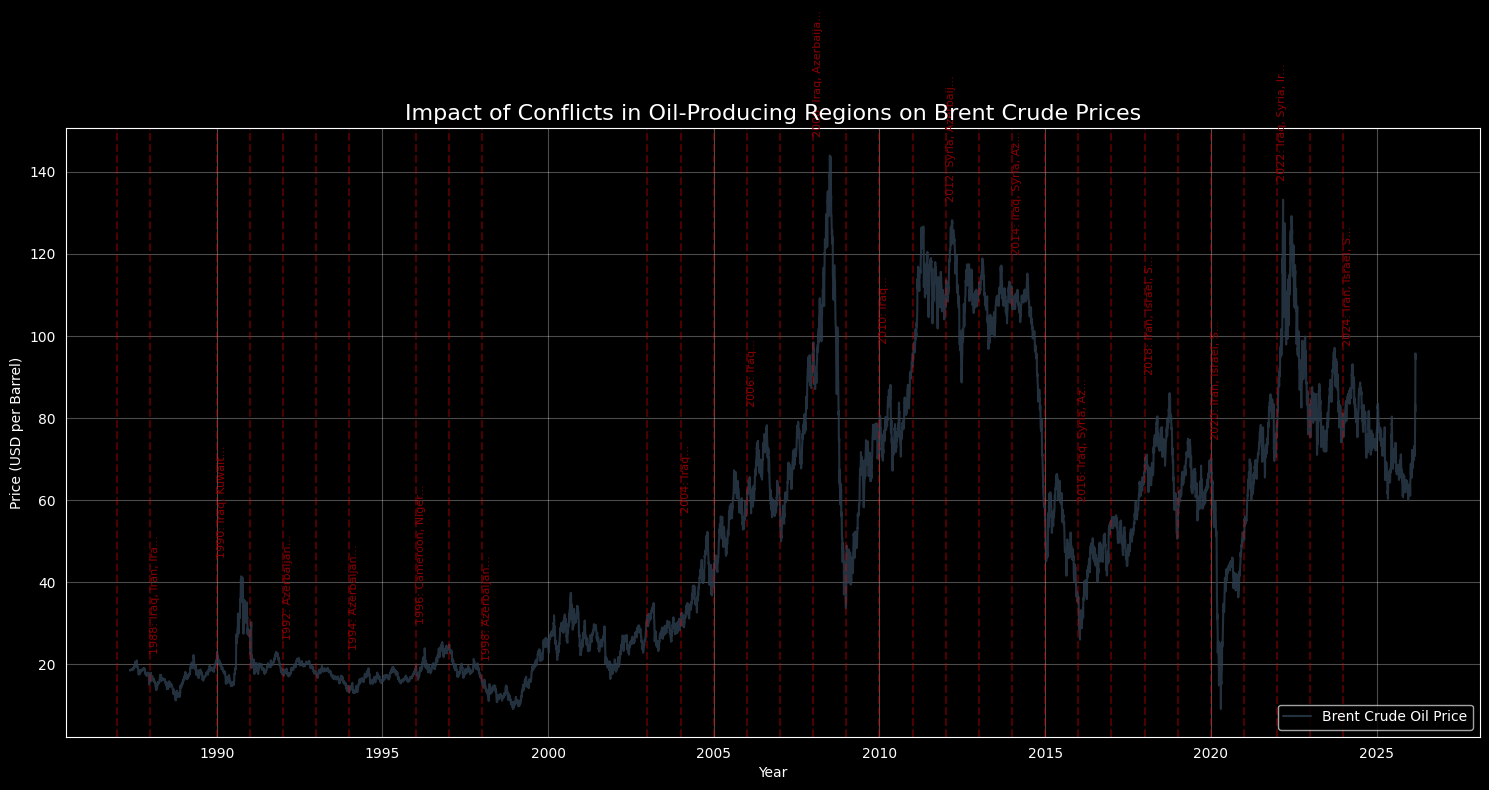

In [31]:
df_brent = df_brent.copy()
df_brent['observation_date'] = pd.to_datetime(df_brent['observation_date'])
# Удаляем пустые значения (иногда в FRED есть пропуски в праздники)
df_brent = df_brent.dropna(subset=['DCOILBRENTEU'])

# 2. Подготовка данных о конфликтах
# Группируем по годам, чтобы не рисовать 10 меток в один год
conflicts_by_year = final_data.groupby('year')['location'].apply(lambda x: ', '.join(set(x))).reset_index()

# 3. Визуализация
plt.figure(figsize=(15, 8))

# Рисуем линию цены
plt.plot(df_brent['observation_date'], df_brent['DCOILBRENTEU'],
         label='Brent Crude Oil Price', color='#2c3e50', linewidth=1.5, alpha=0.8)

# 4. Накладываем конфликты
# Берем только те конфликты, которые попадают в диапазон дат цен (после 1987 года)
relevant_conflicts = conflicts_by_year[conflicts_by_year['year'] >= df_brent['observation_date'].dt.year.min()]

for _, row in relevant_conflicts.iterrows():
    # Находим среднюю цену в этом году для размещения текста
    year_mask = df_brent['observation_date'].dt.year == row['year']
    if year_mask.any():
        price_in_year = df_brent.loc[year_mask, 'DCOILBRENTEU'].max()

        # Рисуем вертикальную линию
        plt.axvline(pd.Timestamp(f"{row['year']}-01-01"), color='red', linestyle='--', alpha=0.3)

        # Добавляем подпись (опционально, если не слишком много данных)
        if row['year'] % 2 == 0: # Подписываем через год, чтобы не было каши
            plt.text(pd.Timestamp(f"{row['year']}-01-01"), price_in_year + 5,
                     f"{row['year']}: {row['location'][:15]}...",
                     rotation=90, fontsize=8, color='darkred')

plt.title('Impact of Conflicts in Oil-Producing Regions on Brent Crude Prices', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Price (USD per Barrel)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

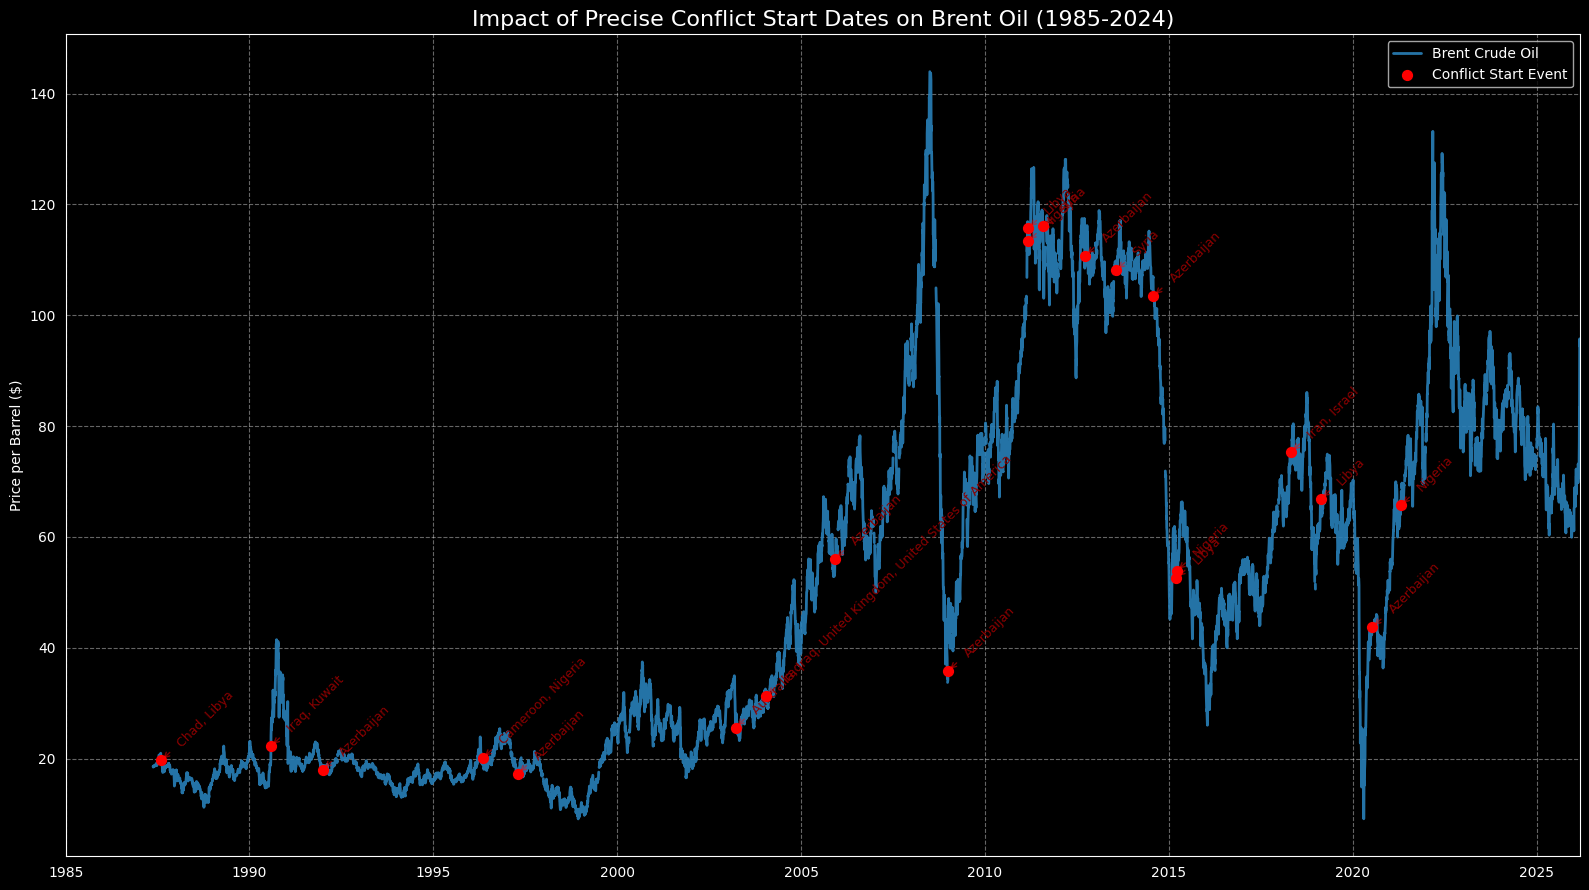

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Подготовка цен (Brent)
df_brent['observation_date'] = pd.to_datetime(df_brent['observation_date'])
df_brent = df_brent.sort_values('observation_date')

# 2. Подготовка конфликтов (берем последние 15 лет для наглядности)
# Преобразуем start_date2 в datetime. Если формат YYYYMMDD, используем format='%Y%m%d'
final_data['start_date2'] = pd.to_datetime(final_data['start_date2'])
recent_conflicts = final_data[final_data['start_date2'] >= '1985-01-01'].copy()

# Удаляем дубликаты по датам, чтобы подписи не накладывались
recent_conflicts = recent_conflicts.drop_duplicates(subset=['start_date2', 'location'])

# 3. Визуализация
plt.figure(figsize=(16, 9))

# Основной график цены
plt.plot(df_brent['observation_date'], df_brent['DCOILBRENTEU'],
         label='Brent Price (USD)', color='#2980b9', linewidth=2, alpha=0.9)

# 4. Наложение точек конфликтов
for _, row in recent_conflicts.iterrows():
    event_date = row['start_date2']

    # Ищем цену нефти в день начала конфликта (или ближайшую доступную)
    price_on_date = df_brent.loc[df_brent['observation_date'] <= event_date, 'DCOILBRENTEU'].iloc[-1]

    # Ставим маркер
    plt.scatter(event_date, price_on_date, color='red', s=50, zorder=5)

    # Добавляем текстовую аннотацию со смещением
    plt.annotate(f"{row['location']}",
                 xy=(event_date, price_on_date),
                 xytext=(10, 10),
                 textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color='red', alpha=0.5),
                 fontsize=9, rotation=45, color='darkred')

# Настройка осей и стиля
plt.xlim(pd.Timestamp('1985-01-01'), df_brent['observation_date'].max())
plt.title('Impact of Precise Conflict Start Dates on Brent Oil (1985-2024)', fontsize=16)
plt.ylabel('Price per Barrel ($)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(['Brent Crude Oil', 'Conflict Start Event'])

plt.tight_layout()
plt.show()


In [44]:
import pandas as pd

# 1. Подготовка цен
df_brent['observation_date'] = pd.to_datetime(df_brent['observation_date'])
df_brent = df_brent.sort_values('observation_date').reset_index(drop=True)

def get_event_stats(row, price_df, window_days=20):
    start_date = pd.to_datetime(row['start_date2'])

    # Находим индекс ближайшего торгового дня к дате начала конфликта
    start_idx_list = price_df.index[price_df['observation_date'] >= start_date].tolist()
    if not start_idx_list:
        return pd.Series([None, None, None])

    start_idx = start_idx_list[0]
    start_price = price_df.loc[start_idx, 'DCOILBRENTEU']

    # Берем окно в 20 торговых дней
    window = price_df.iloc[start_idx : start_idx + window_days]

    if window.empty:
        return pd.Series([start_price, None, None])

    peak_price = window['DCOILBRENTEU'].max()
    price_change_pct = ((peak_price - start_price) / start_price) * 100

    return pd.Series([start_price, peak_price, price_change_pct])

oil_weights = {
    'Russia (Soviet Union)': 10.0, 'Saudi Arabia': 10.0, 'United States': 13.0,
    'Iraq': 4.4, 'Iran': 4.0, 'United Arab Emirates': 3.8, 'Kuwait': 2.6,
    'Nigeria': 1.6, 'Libya': 1.2, 'Venezuela': 0.9, 'Angola': 1.1
}

# Оставляем только тех, кто добывает > 1.0 млн барр/сут
heavyweight_locations = [k for k, v in oil_weights.items() if v >= 1.0]

# Фильтруем ваш датасет конфликтов
filtered_conflicts = final_data[
    final_data['location'].str.contains('|'.join(heavyweight_locations), na=False)
].copy()
# 2. Применяем расчет к вашему отфильтрованному датасету (heavyweight_locations)
# Создаем новые колонки
filtered_conflicts[['start_price', 'peak_price_20d', 'jump_pct']] = filtered_conflicts.apply(
    lambda r: get_event_stats(r, df_brent), axis=1
)

# 3. Сортируем по силе влияния (jump_pct)
top_impact_conflicts = filtered_conflicts.dropna(subset=['jump_pct']).sort_values(by='jump_pct', ascending=False)

# Выведем ТОП-10 самых "влиятельных" конфликтов в истории вашего датасета
print(top_impact_conflicts[['year', 'location', 'start_date2', 'start_price', 'peak_price_20d', 'jump_pct']].head(10))


      year      location start_date2  start_price  peak_price_20d   jump_pct
2314  1990  Iraq, Kuwait  1990-08-02        22.25           32.35  45.393258
2315  1991  Iraq, Kuwait  1990-08-02        22.25           32.35  45.393258
132   2019       Nigeria  2015-03-22        53.82           61.31  13.916760
131   2018       Nigeria  2015-03-22        53.82           61.31  13.916760
134   2021       Nigeria  2015-03-22        53.82           61.31  13.916760
135   2022       Nigeria  2015-03-22        53.82           61.31  13.916760
133   2020       Nigeria  2015-03-22        53.82           61.31  13.916760
130   2017       Nigeria  2015-03-22        53.82           61.31  13.916760
136   2023       Nigeria  2015-03-22        53.82           61.31  13.916760
137   2024       Nigeria  2015-03-22        53.82           61.31  13.916760


/tmp/ipykernel_30903/1781373247.py:40: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  final_data['location'].str.contains('|'.join(heavyweight_locations), na=False)
